   dataset  mean_trips_per_day_full_period  mean_trips_per_day_measured_days_only  median_trips_per_day_full_period  median_trips_per_day_measured_days_only
0  GeoLife                        1.269143                               2.810157                           1.00000                                 2.625000
1    rMove                        3.094527                               3.166509                           2.50000                                 2.500000
2  Spectus                        1.954480                               2.905578                           1.73924                                 2.709208


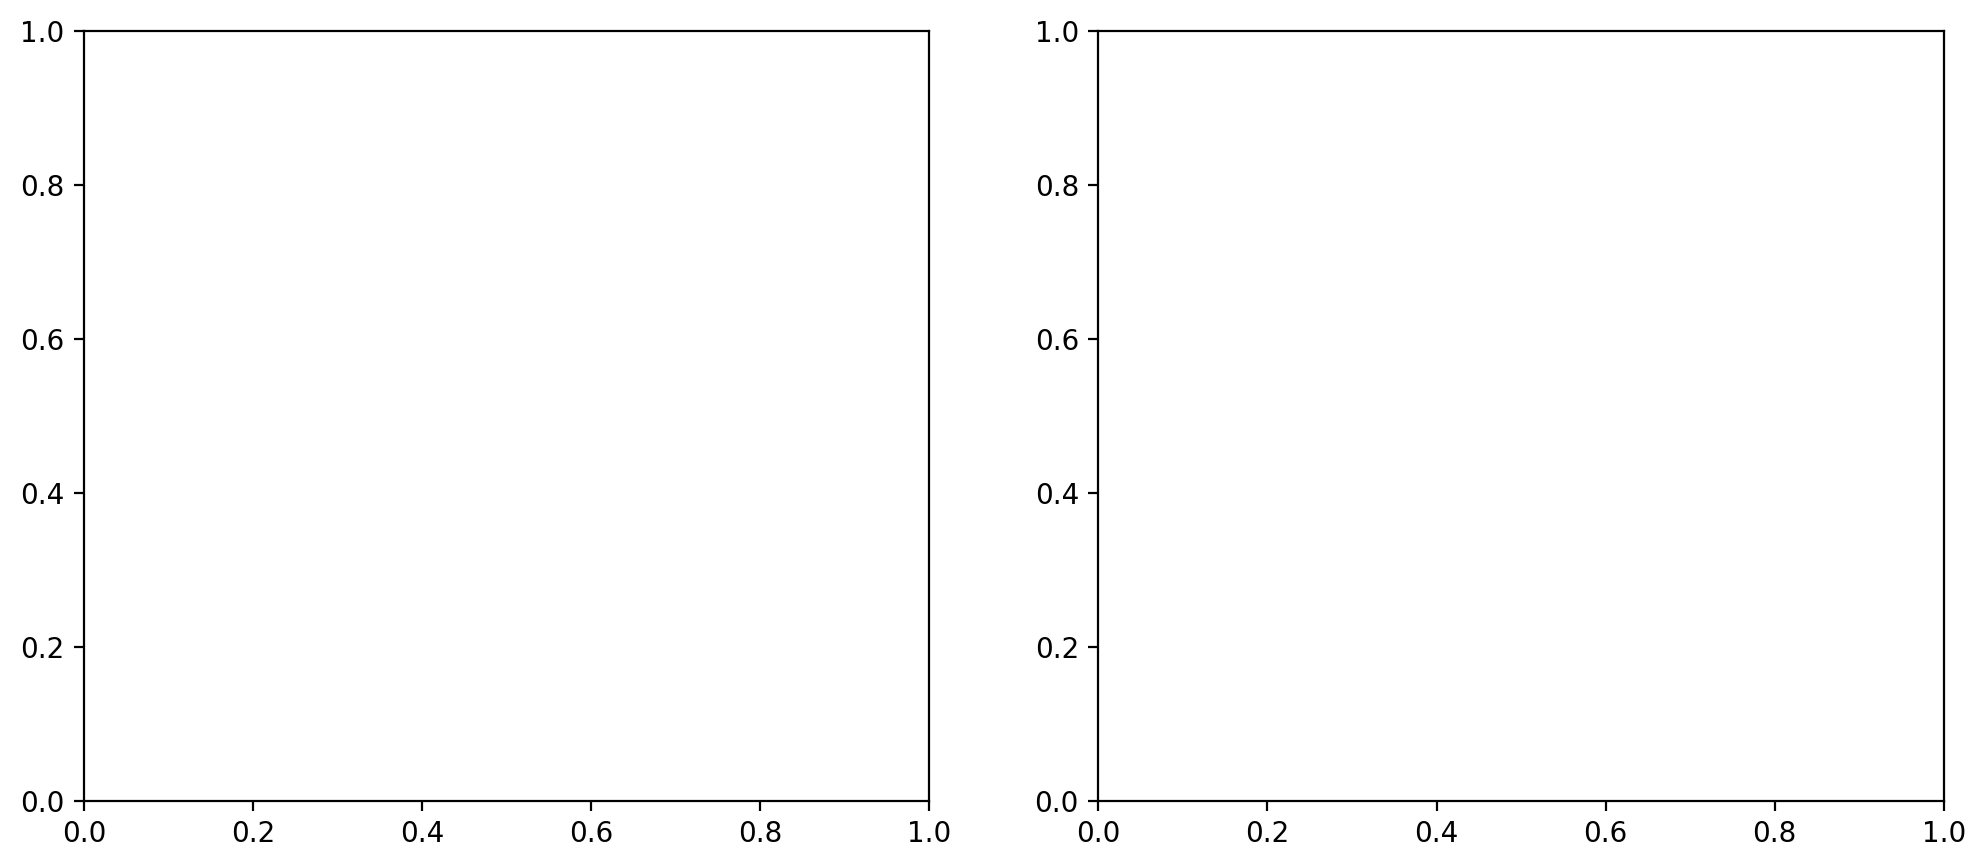

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
import pandas as pd

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5), dpi=200)

axes2_flat = axes2.flat

means_and_medians = []

geolife_averages = pd.read_csv(f'./data/Geolife/20260727_geolife_per_day_averages.csv', low_memory=False)
geolife_means_and_medians = {
    'dataset': 'GeoLife',
    'mean_trips_per_day_full_period': geolife_averages['trips_per_day_for_total_period'].mean(),
    'mean_trips_per_day_measured_days_only': geolife_averages['trips_per_day_for_measured_days'].mean(),
    'median_trips_per_day_full_period': geolife_averages['trips_per_day_for_total_period'].median(),
    'median_trips_per_day_measured_days_only': geolife_averages['trips_per_day_for_measured_days'].median()
}
means_and_medians.append(geolife_means_and_medians)

rmove_averages = pd.read_csv(f'./data/rMove/20260727_rmove_per_day_averages.csv', low_memory=False)
rmove_means_and_medians = {
    'dataset': 'rMove',
    'mean_trips_per_day_full_period': rmove_averages['trips_per_day_for_total_period'].mean(),
    'mean_trips_per_day_measured_days_only': rmove_averages['trips_per_day_for_measured_days'].mean(),
    'median_trips_per_day_full_period': rmove_averages['trips_per_day_for_total_period'].median(),
    'median_trips_per_day_measured_days_only': rmove_averages['trips_per_day_for_measured_days'].median()
}
means_and_medians.append(rmove_means_and_medians)

spectus_averages = pd.read_csv(f'./data/Spectus/Lyra_Processed/20260727_spectus_per_day_averages.csv', low_memory=False)
spectus_means_and_medians = {
    'dataset': 'Spectus',
    'mean_trips_per_day_full_period': spectus_averages['trips_per_day_for_total_period'].mean(),
    'mean_trips_per_day_measured_days_only': spectus_averages['trips_per_day_for_measured_days'].mean(),
    'median_trips_per_day_full_period': spectus_averages['trips_per_day_for_total_period'].median(),
    'median_trips_per_day_measured_days_only': spectus_averages['trips_per_day_for_measured_days'].median()
}
means_and_medians.append(spectus_means_and_medians)

means_and_medians_df = pd.DataFrame(means_and_medians)
print(means_and_medians_df.to_string())

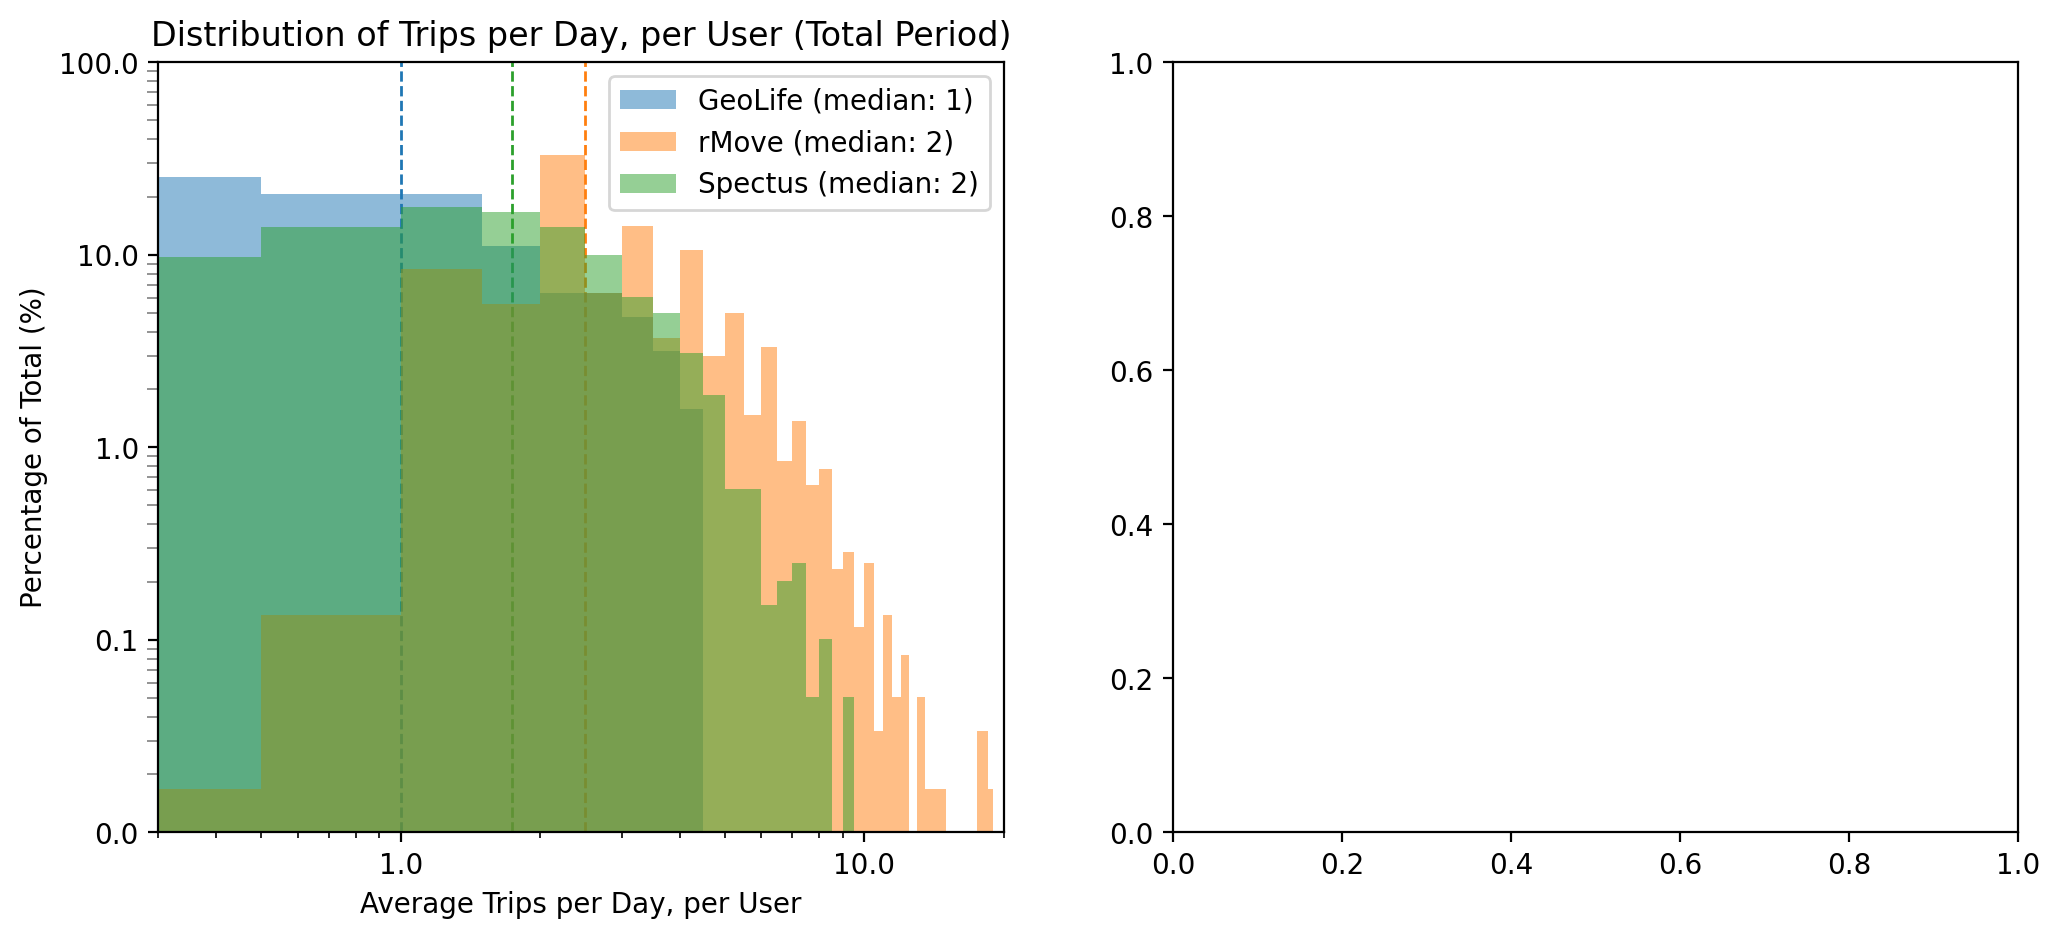

In [2]:
# ax2 = axes2_flat[0]
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
import pandas as pd

ax2 = axes2_flat[0]

filtered_geolife = geolife_averages
filtered_rmove = rmove_averages
filtered_spectus = spectus_averages

weights_geolife = np.ones_like(filtered_geolife['trips_per_day_for_total_period']) / len(
    filtered_geolife['trips_per_day_for_total_period']) * 100
weights_rmove = np.ones_like(filtered_rmove['trips_per_day_for_total_period']) / len(
    filtered_rmove['trips_per_day_for_total_period']) * 100
weights_spectus = np.ones_like(filtered_spectus['trips_per_day_for_total_period']) / len(
    filtered_spectus['trips_per_day_for_total_period']) * 100

median_geolife = filtered_geolife['trips_per_day_for_total_period'].median()
median_rmove = filtered_rmove['trips_per_day_for_total_period'].median()
median_spectus = filtered_spectus['trips_per_day_for_total_period'].median()

ax2.axvline(median_geolife, color='C0', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(median_rmove, color='C1', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(median_spectus, color='C2', linestyle='--', linewidth=1, zorder=1)

ax2.hist(filtered_geolife['trips_per_day_for_total_period'], bins=40, range=(0, 20), alpha=0.5,
         label=f'GeoLife (median: {median_geolife:.0f})', weights=weights_geolife, zorder=2)
ax2.hist(filtered_rmove['trips_per_day_for_total_period'], bins=40, range=(0, 20), alpha=0.5,
         label=f'rMove (median: {median_rmove:.0f})', weights=weights_rmove, zorder=2)
ax2.hist(filtered_spectus['trips_per_day_for_total_period'], bins=40, range=(0, 20), alpha=0.5,
         label=f'Spectus (median: {median_spectus:.0f})', weights=weights_spectus, zorder=2)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.3, 20)
ax2.set_ylim(0.01, 100)
ax2.tick_params(axis='y', which='minor', length=4, color='gray')
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

ax2.set_xlabel('Average Trips per Day, per User')
ax2.set_ylabel('Percentage of Total (%)')
ax2.set_title('Distribution of Trips per Day, per User (Total Period)')
ax2.legend()

fig2

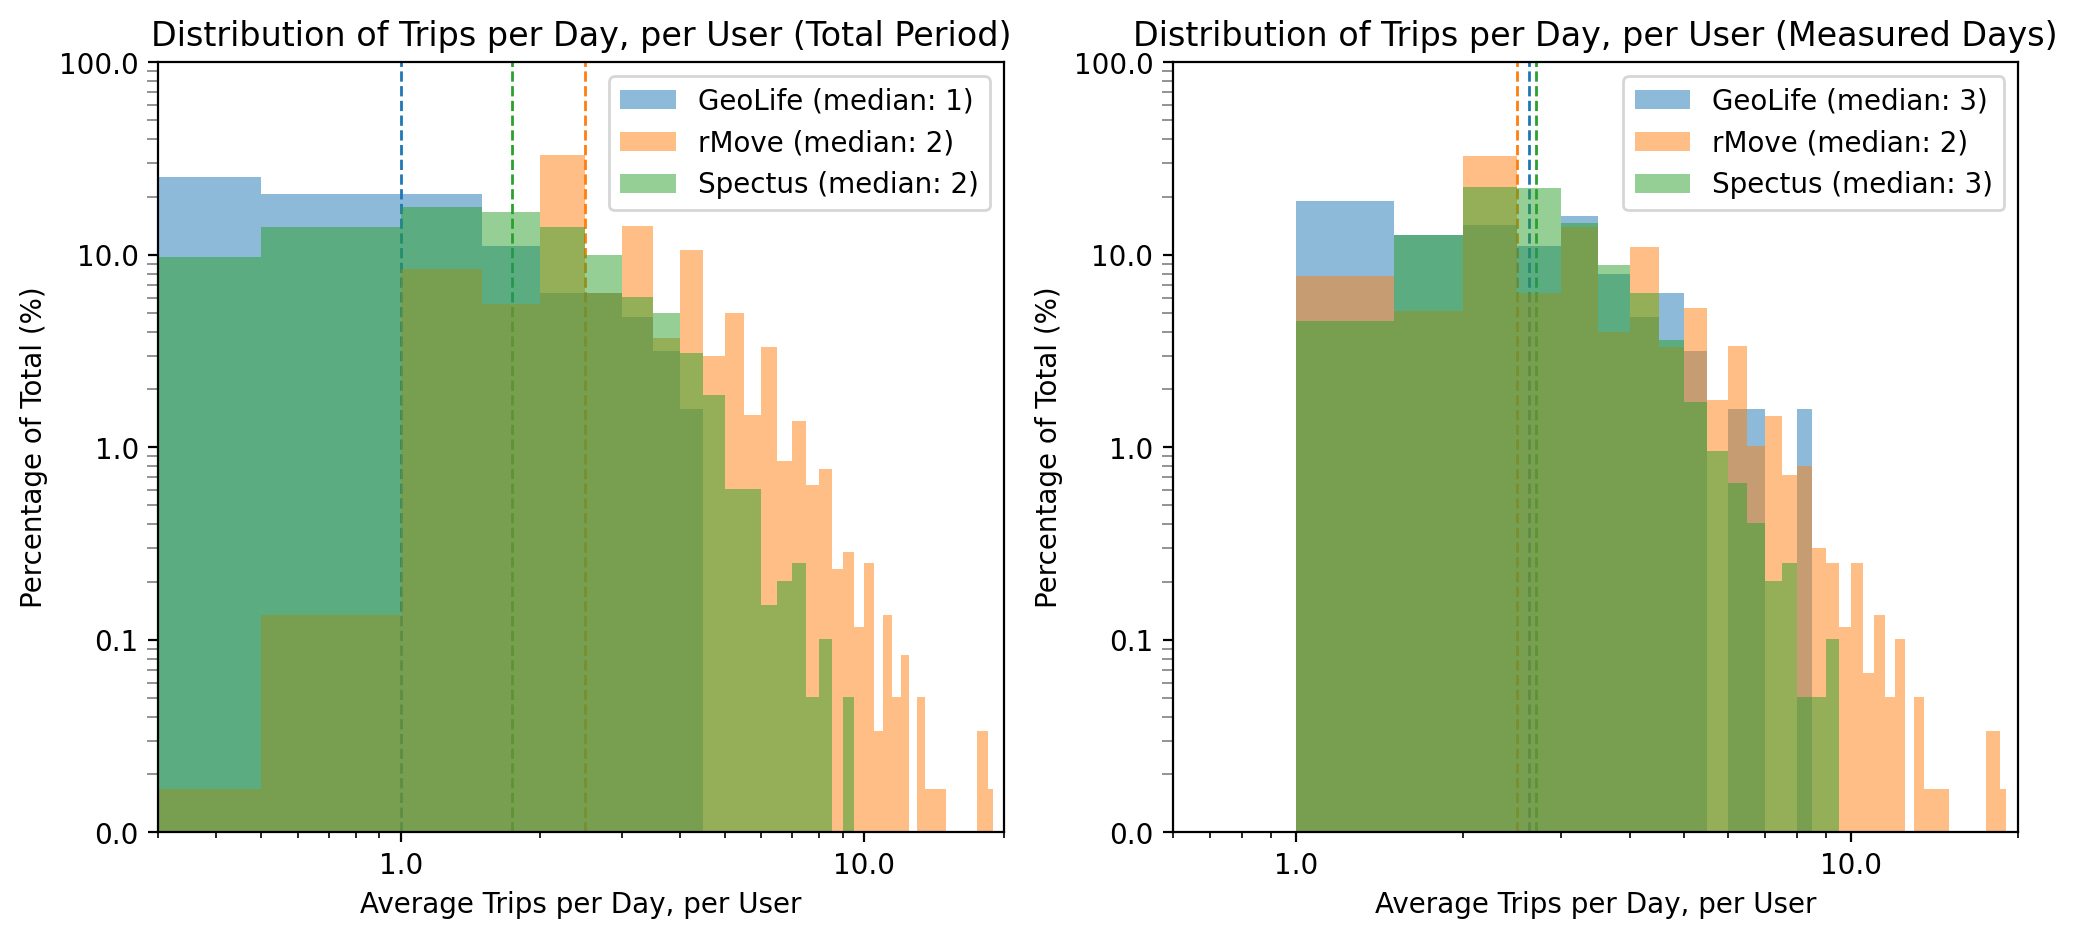

In [3]:
# ax2 = axes2_flat[0]
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import numpy as np
import pandas as pd

ax2 = axes2_flat[1]

filtered_geolife = geolife_averages
filtered_rmove = rmove_averages
filtered_spectus = spectus_averages

weights_geolife = np.ones_like(filtered_geolife['trips_per_day_for_measured_days']) / len(filtered_geolife['trips_per_day_for_measured_days']) * 100
weights_rmove = np.ones_like(filtered_rmove['trips_per_day_for_measured_days']) / len(filtered_rmove['trips_per_day_for_measured_days']) * 100
weights_spectus = np.ones_like(filtered_spectus['trips_per_day_for_measured_days']) / len(filtered_spectus['trips_per_day_for_measured_days']) * 100

median_geolife = filtered_geolife['trips_per_day_for_measured_days'].median()
median_rmove = filtered_rmove['trips_per_day_for_measured_days'].median()
median_spectus = filtered_spectus['trips_per_day_for_measured_days'].median()

ax2.axvline(median_geolife, color='C0', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(median_rmove, color='C1', linestyle='--', linewidth=1, zorder=1)
ax2.axvline(median_spectus, color='C2', linestyle='--', linewidth=1, zorder=1)

ax2.hist(filtered_geolife['trips_per_day_for_measured_days'], bins=40, range=(0, 20), alpha=0.5, label=f'GeoLife (median: {median_geolife:.0f})', weights=weights_geolife, zorder=2)
ax2.hist(filtered_rmove['trips_per_day_for_measured_days'], bins=40, range=(0, 20), alpha=0.5, label=f'rMove (median: {median_rmove:.0f})', weights=weights_rmove, zorder=2)
ax2.hist(filtered_spectus['trips_per_day_for_measured_days'], bins=40, range=(0, 20), alpha=0.5, label=f'Spectus (median: {median_spectus:.0f})', weights=weights_spectus, zorder=2)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.6, 20)
ax2.set_ylim(0.01, 100)
ax2.tick_params(axis='y', which='minor', length=4, color='gray')
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.yaxis.set_major_formatter(ScalarFormatter())

ax2.set_xlabel('Average Trips per Day, per User')
ax2.set_ylabel('Percentage of Total (%)')
ax2.set_title('Distribution of Trips per Day, per User (Measured Days)')
ax2.legend()

fig2

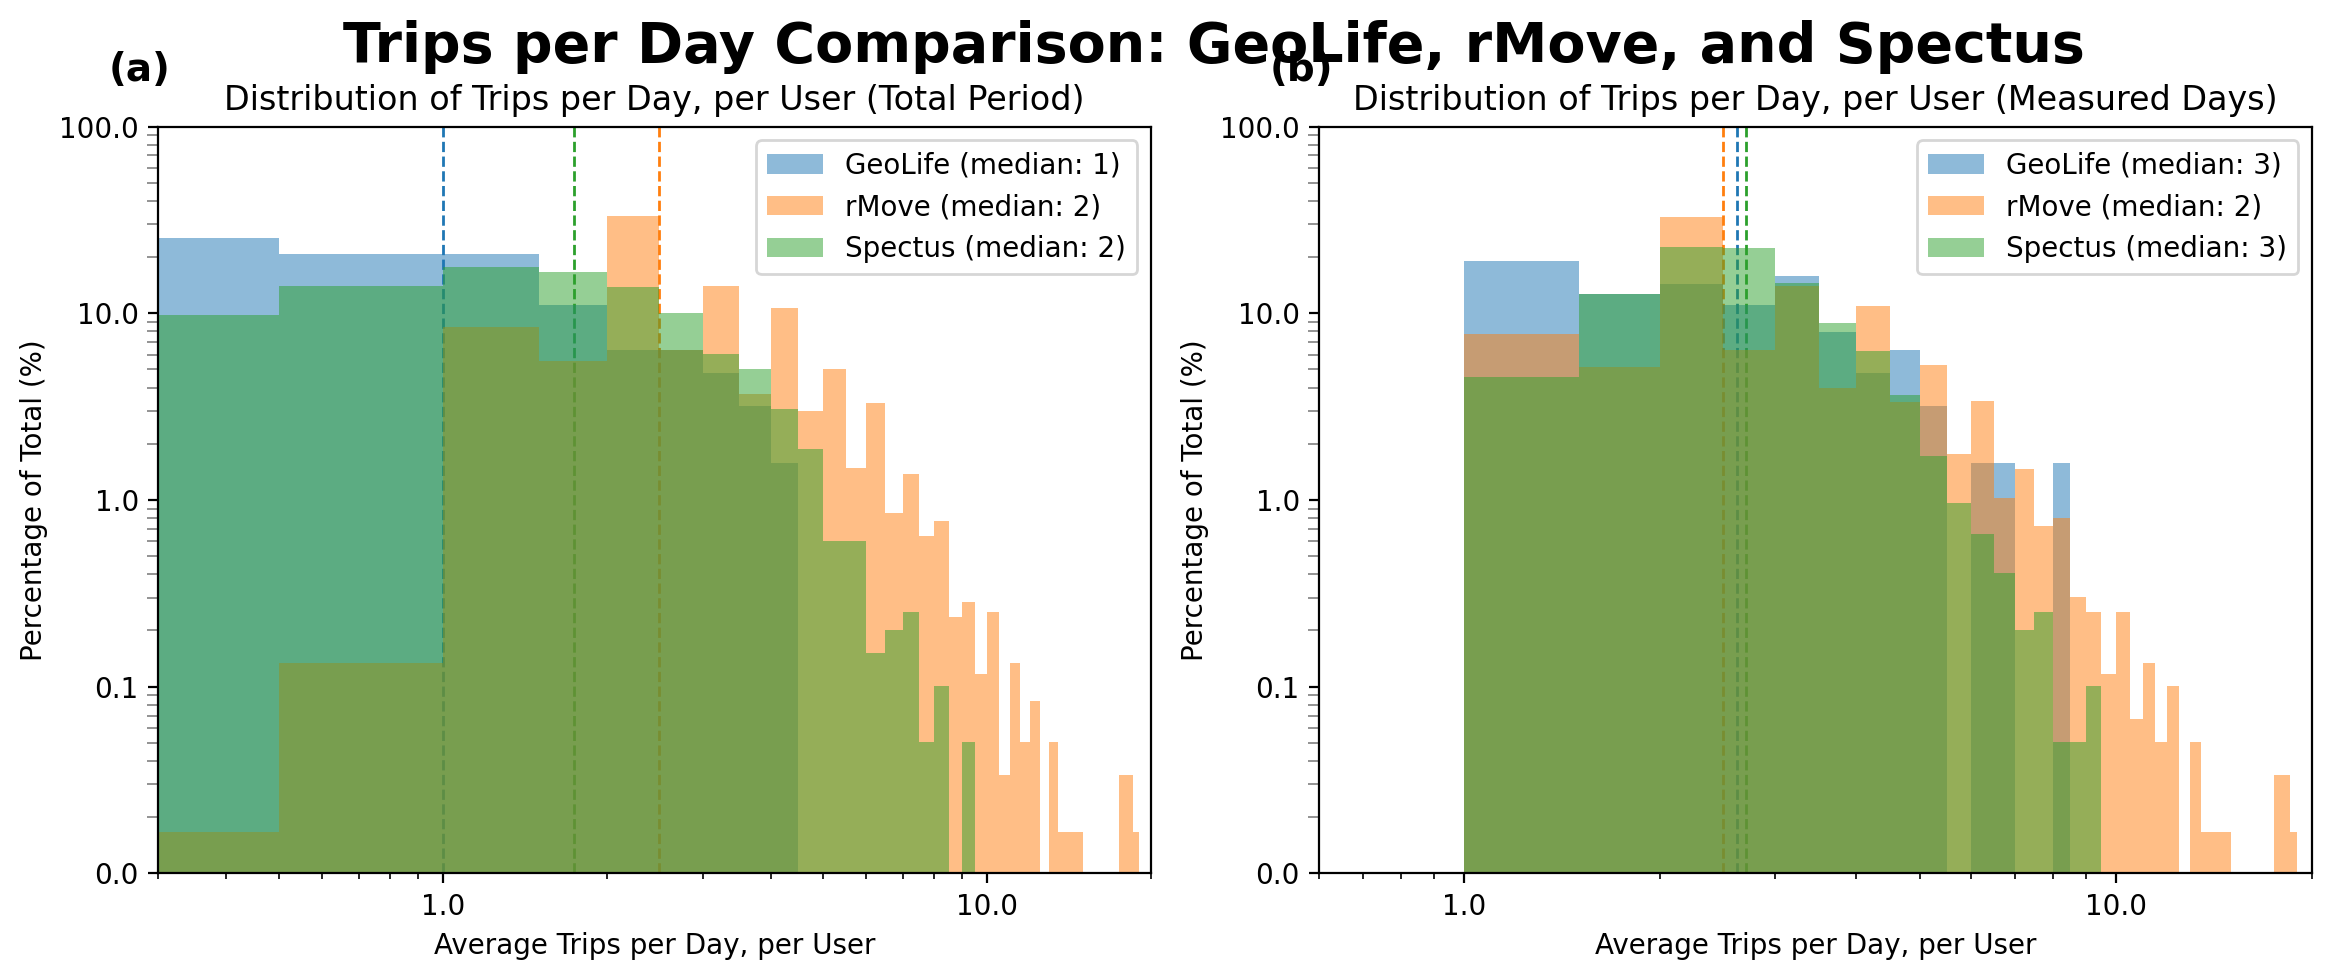

In [4]:
labels = ['a', 'b']
for ax, label in zip(axes2_flat, labels):
    # Place label in the upper-left corner of each subplot
    ax.text(
        -0.05, 1.05,          # x, y in axes coordinates
        f'({label})',         # e.g. (a), (b), ...
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='bottom',
        ha='left'
    )

fig2.tight_layout(rect=[0.01, 0.01, 0.99, 0.98])
fig2.subplots_adjust(hspace=0.4)
fig2.suptitle("Trips per Day Comparison: GeoLife, rMove, and Spectus", fontsize=20, fontweight='bold', x=0.52, y=0.98)
fig2.savefig("images/Overlapped_Trips_per_Day_Graphs.png", dpi=200)

fig2